In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("messy_ecommerce_sales_data.csv")

In [4]:
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


In [5]:
df.isnull().sum()

ID                 0
 Customer_Name     0
Order_ID           0
Order_Date         0
 Product           0
Category           8
Quantity           5
Price              5
Payment_Method     0
Status             0
Total             14
dtype: int64

In [11]:
df.dtypes

ID                  int64
 Customer_Name        str
Order_ID              str
Order_Date            str
 Product              str
Category              str
Quantity              str
Price                 str
Payment_Method        str
Status                str
Total             float64
dtype: object

In [7]:
df["Total"]=df["Total"]=pd.to_numeric(df["Total"])

In [12]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [13]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Price'] = df['Price'].fillna(df['Price'].median())

In [15]:
df['Total'] = df['Quantity'] * df['Price']

In [16]:
df.isnull().sum()

ID                0
 Customer_Name    0
Order_ID          0
Order_Date        0
 Product          0
Category          8
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

In [17]:
df.columns

Index(['ID', ' Customer_Name', 'Order_ID', 'Order_Date', ' Product',
       'Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total'],
      dtype='str')

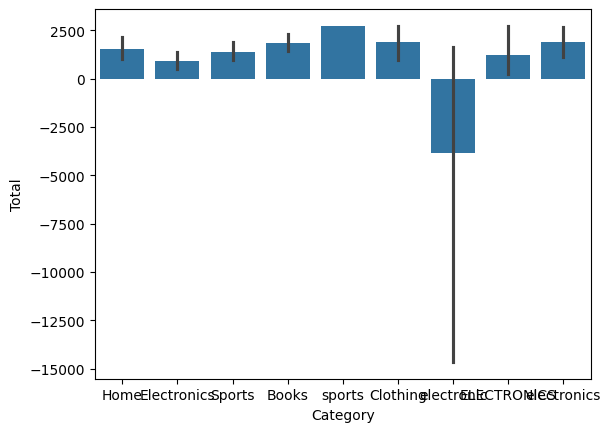

In [22]:
sns.barplot(x='Category', y='Total', data=df)
plt.show()



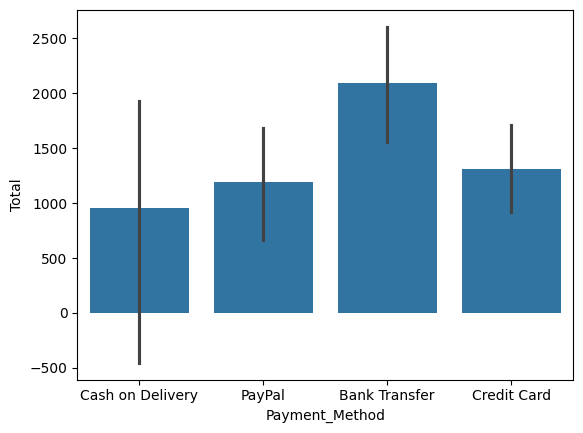

In [23]:
sns.barplot(x='Payment_Method', y='Total', data=df)
plt.show()



#### Feature Engineering

In [8]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
df.isnull().sum()

ID                             0
Total                          0
 Customer_Name_Customer_101    0
 Customer_Name_Customer_102    0
 Customer_Name_Customer_103    0
                              ..
Payment_Method_PayPal          0
Status_Delivered               0
Status_Processing              0
Status_Returned                0
Status_Shipped                 0
Length: 420, dtype: int64

In [12]:
df["Total"] = df["Total"].fillna(0)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop('Total', axis=1)
y = df['Total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 5128.997573019739
MSE: 54162834.217165105
R2 Score: -39.36557073823001


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X = df.drop('Status_Delivered', axis=1)
y = df['Status_Delivered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9047619047619048
[[19  0]
 [ 2  0]]
